In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import files

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving wdbc.data to wdbc.data


In [ ]:
# Step 2: Load dataset
df = pd.read_csv('wdbc.data', header=None)
# Step 3: Check dataset
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (569, 32)
         0  1      2      3       4       5        6        7       8   \
0    842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001   
1    842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869   
2  84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974   
3  84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414   
4  84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980   

        9   ...     22     23      24      25      26      27      28      29  \
0  0.14710  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.07017  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.12790  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.10520  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.10430  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       30       31  
0  0.4601  0.11890  
1

In [ ]:
# Step 4: Prepare Features and Labels
X = df.iloc[:, 2:]  # Columns 2 to end: 30 features
y = df.iloc[:, 1].map({'B': 0, 'M': 1})  # 0=Benign, 1=Malignant

# Step 5: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
# Step 7: Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 8: Predictions and Evaluation
y_pred = rf.predict(X_test)

print("\nInitial Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Initial Model Accuracy: 0.9649122807017544

Confusion Matrix:
 [[107   0]
 [  6  58]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



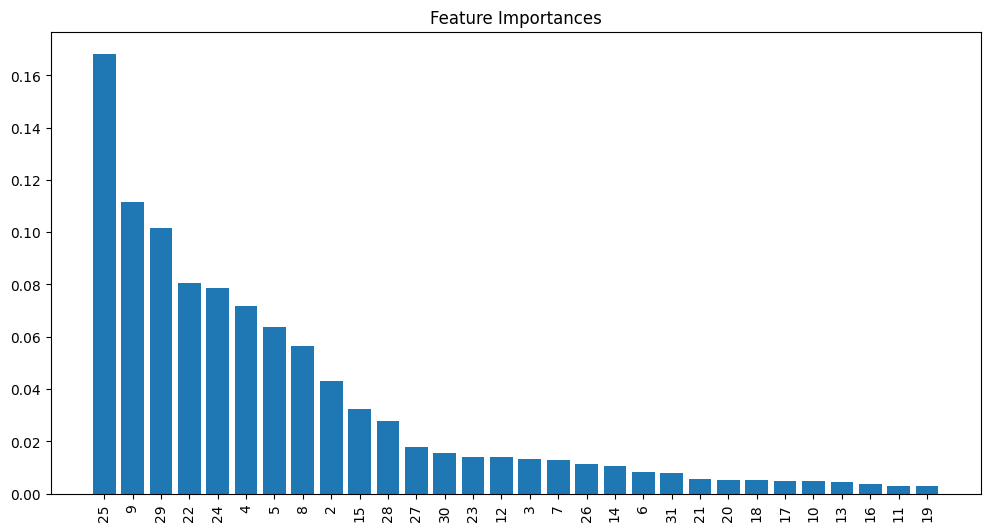

In [ ]:
# Step 9: Plot Feature Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), df.columns[2:][indices], rotation=90)
plt.show()

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Step 11: Evaluate Best Model on Test Set
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("\nTuned Model Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score: 0.9571835443037975

Tuned Model Test Accuracy: 0.9707602339181286

Confusion Matrix:
 [[107   0]
 [  5  59]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



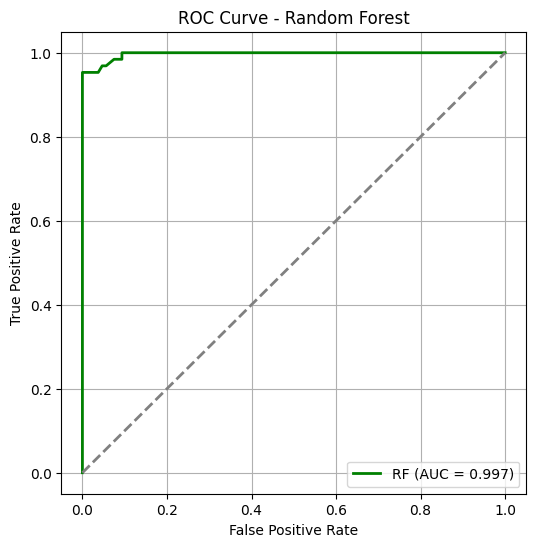

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Step 1: Train Random Forest ---
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

# --- Step 2: Predict probabilities ---
y_proba_rf = rf.predict_proba(X_test)[:, 1]   # probability of positive class

# --- Step 3: ROC curve ---
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# --- Step 4: Plot ---
plt.figure(figsize=(6, 6))
plt.plot(fpr_rf, tpr_rf, color="green", lw=2, label=f"RF (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [ ]:
print("fpr_rf =", list(fpr_rf))
print("tpr_rf =", list(tpr_rf))
print("roc_auc_rf =", roc_auc_rf)


fpr_rf = [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.018691588785046728), np.float64(0.037383177570093455), np.float64(0.04672897196261682), np.float64(0.056074766355140186), np.float64(0.07476635514018691), np.float64(0.09345794392523364), np.float64(0.09345794392523364), np.float64(0.11214953271028037), np.float64(0.14018691588785046), np.float64(0.1588785046728972), np.float64(0.17757009345794392), np.float64(0.21495327102803738), np.float64(0.22429906542056074), np.float64(0.2616822429906542), np.float64(0.2897196261682243), np.float64(0.4485981308411215), np.float64(0.5700934579439252), np.float64(1.0)]
tpr_rf = [np.float64(0.0), np.float64(0.390625), np.float64(0.5), np.float64(0.625), np.float64(0.65625), np.float64(0.71875), np.float64(0.75), np.float64(0.78125), np.float64(0.953125), np.float64(0.953125), np.float64(0.953125), np.float64(0.96875), np.float